In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
customer = pd.read_csv("../data/processed/customer_features_final.csv")

In [4]:
customer.head()

,household_key,recency,frequency,monetary,avg_basket_value,total_quantity,avg_quantity,total_discount,discount_rate,unique_products,...,KID_CATEGORY_DESC,campaigns_received,campaign_types,coupon_redeemer,campaign_rate,coupon_per_campaign,unique_departments,unique_categories,unique_brands,category_diversity
0,1,5,86,4330.16,50.350698,1997,23.220930,697.04,0.160973,677,...,None/Unknown,0.0,0.0,1,0.000000,0.0,0.0,0.0,0.0,0.000000
1,2,43,45,1954.34,43.429778,834,18.533333,334.99,0.171408,546,...,Unknown,8.0,3.0,0,0.177778,0.0,13.0,128.0,2.0,2.844444
2,3,8,47,2653.21,56.451277,8540,181.702128,675.16,0.254469,516,...,Unknown,1.0,1.0,0,0.021277,0.0,12.0,141.0,2.0,3.000000
3,4,84,30,1200.11,40.003667,382,12.733333,115.65,0.096366,164,...,Unknown,3.0,2.0,0,0.100000,0.0,12.0,110.0,2.0,3.666667
4,5,8,40,779.06,19.476500,245,6.125000,118.33,0.151888,199,...,Unknown,1.0,1.0,0,0.025000,0.0,9.0,63.0,2.0,1.575000


In [5]:
customer.shape


(2500, 30)

In [6]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   household_key        2500 non-null   int64  
 1   recency              2500 non-null   int64  
 2   frequency            2500 non-null   int64  
 3   monetary             2500 non-null   float64
 4   avg_basket_value     2500 non-null   float64
 5   total_quantity       2500 non-null   int64  
 6   avg_quantity         2500 non-null   float64
 7   total_discount       2500 non-null   float64
 8   discount_rate        2500 non-null   float64
 9   unique_products      2500 non-null   int64  
 10  shopping_days        2500 non-null   int64  
 11  spend_per_day        2500 non-null   float64
 12  coupon_redemptions   2500 non-null   float64
 13  coupon_rate          2500 non-null   float64
 14  classification_1     2500 non-null   str    
 15  classification_2     2500 non-null   str    
 16 

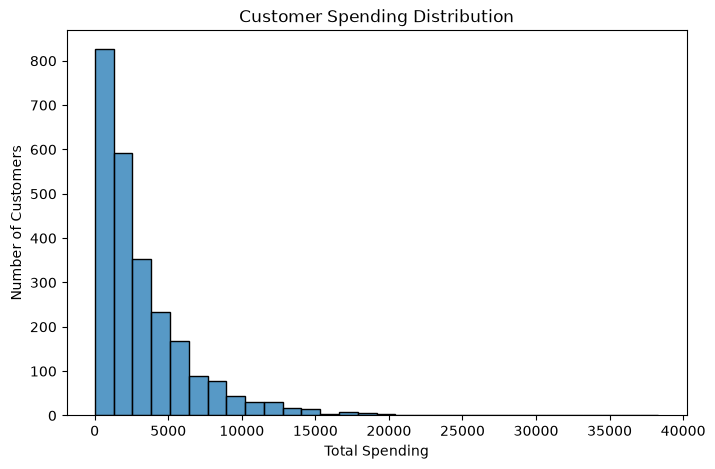

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(customer["monetary"], bins=30)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

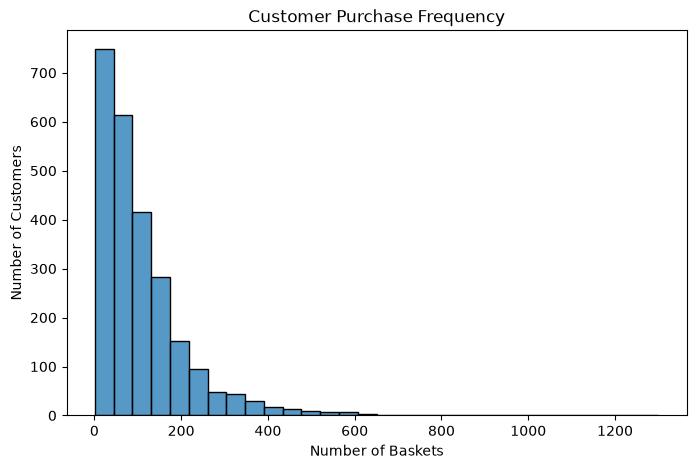

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(customer["frequency"], bins=30)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Baskets")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
numeric = customer.select_dtypes(include="number")

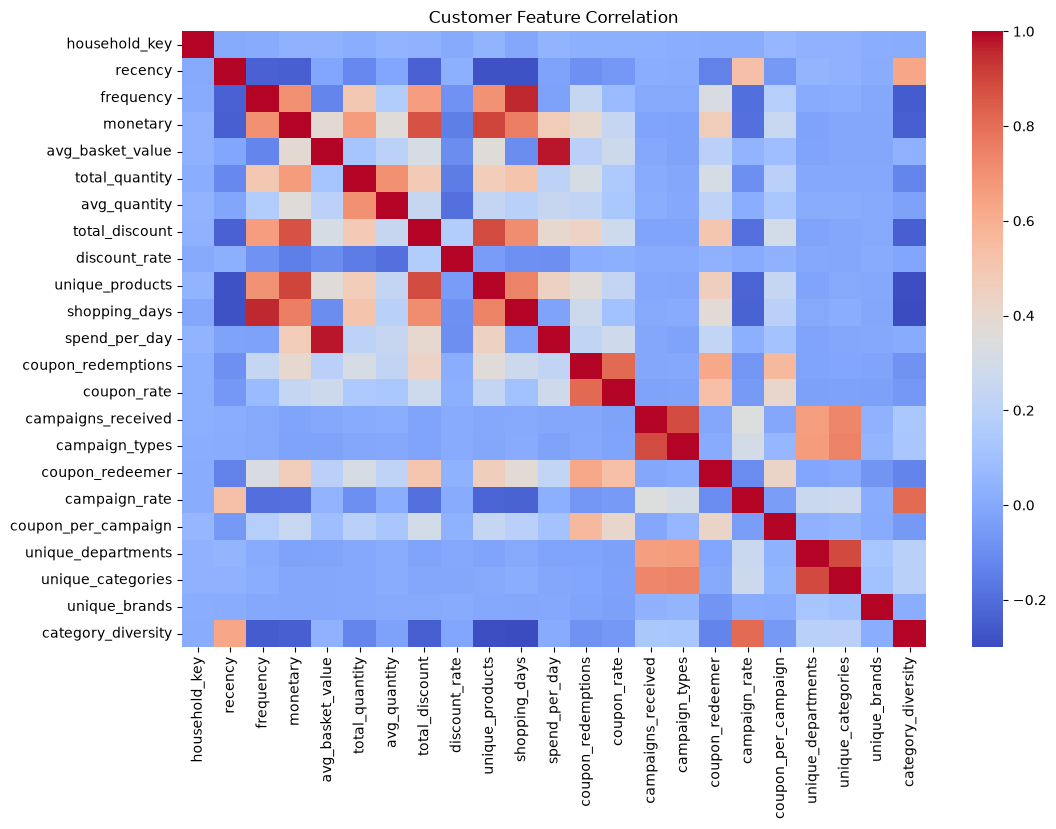

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric.corr(), cmap="coolwarm")
plt.title("Customer Feature Correlation")
plt.show()

In [11]:
features = [
    "recency",
    "frequency",
    "monetary",
    "avg_basket_value",
    "total_quantity",
    "avg_quantity",
    "discount_rate",
    "unique_products",
    "shopping_days",
    "spend_per_day",
    "coupon_rate",
    "campaign_rate"
]

X = customer[features]

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.cluster import KMeans
scores = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    scores.append(model.inertia_)
print(scores)

[23058.459025584718, 20488.69412704411, 18348.648980024936, 16707.18194634407, 15544.531744769856, 14319.986919946088, 13229.001234100848]


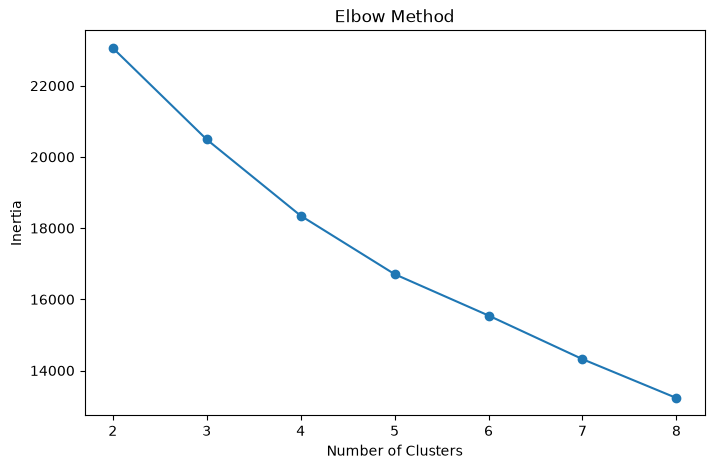

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 9), scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [15]:
from sklearn.metrics import silhouette_score
silhouette = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)
print(silhouette)

[0.3590487757295758, 0.2694211395075611, 0.28061149012876724, 0.26906117147712094, 0.1839739435008452, 0.20117379584351416, 0.2033502838664732]


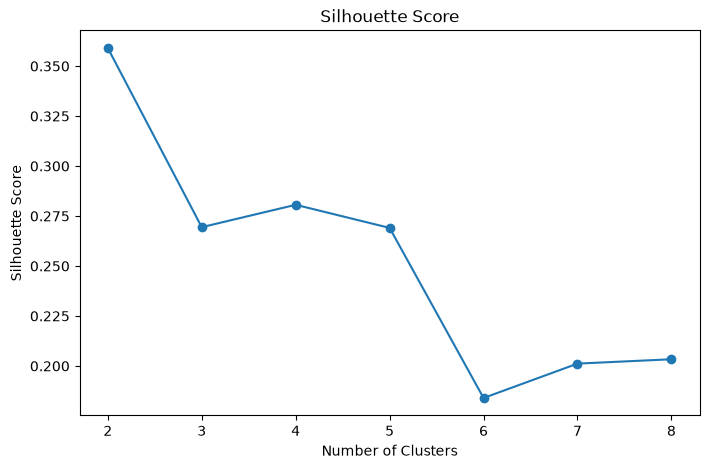

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 9), silhouette, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [17]:
model = KMeans(n_clusters=4, random_state=42, n_init=10)
customer["segment"] = model.fit_predict(X_scaled)

In [36]:
customer["segment"].value_counts().sort_index()

segment
0     507
1    1560
2     369
3      64
Name: count, dtype: int64

In [19]:
segment_profile = customer.groupby("segment")[features].mean()
segment_profile

,recency,frequency,monetary,avg_basket_value,total_quantity,avg_quantity,discount_rate,unique_products,shopping_days,spend_per_day,coupon_rate,campaign_rate
segment,,,,,,,,,,,,
0,15.187377,82.585799,4452.674418,57.486199,67814.347140,808.609121,0.171546,755.329389,73.477318,63.810461,0.016825,0.054370
1,22.328205,77.709615,1674.703615,22.963534,33574.156410,424.073282,0.192695,365.349359,67.476282,25.910290,0.001513,0.066801
2,4.826558,305.899729,8591.961843,32.035668,470436.455285,1904.545987,0.169039,1201.905149,223.712737,40.706449,0.013517,0.011138
3,306.593750,7.953125,265.399844,35.345539,5265.812500,663.508808,0.209005,79.203125,7.296875,39.048695,0.000000,1.033990


In [20]:
segment_profile.round(2)

,recency,frequency,monetary,avg_basket_value,total_quantity,avg_quantity,discount_rate,unique_products,shopping_days,spend_per_day,coupon_rate,campaign_rate
segment,,,,,,,,,,,,
0,15.19,82.59,4452.67,57.49,67814.35,808.61,0.17,755.33,73.48,63.81,0.02,0.05
1,22.33,77.71,1674.70,22.96,33574.16,424.07,0.19,365.35,67.48,25.91,0.00,0.07
2,4.83,305.90,8591.96,32.04,470436.46,1904.55,0.17,1201.91,223.71,40.71,0.01,0.01
3,306.59,7.95,265.40,35.35,5265.81,663.51,0.21,79.20,7.30,39.05,0.00,1.03


In [21]:
segment_names = {
    0: "High-Value Loyal",
    1: "Regular Customers",
    2: "VIP Power Customers",
    3: "At-Risk Customers"
}

customer["segment_name"] = customer["segment"].map(segment_names)

In [22]:
customer["segment_name"].value_counts()

segment_name
Regular Customers      1560
High-Value Loyal        507
VIP Power Customers     369
At-Risk Customers        64
Name: count, dtype: int64

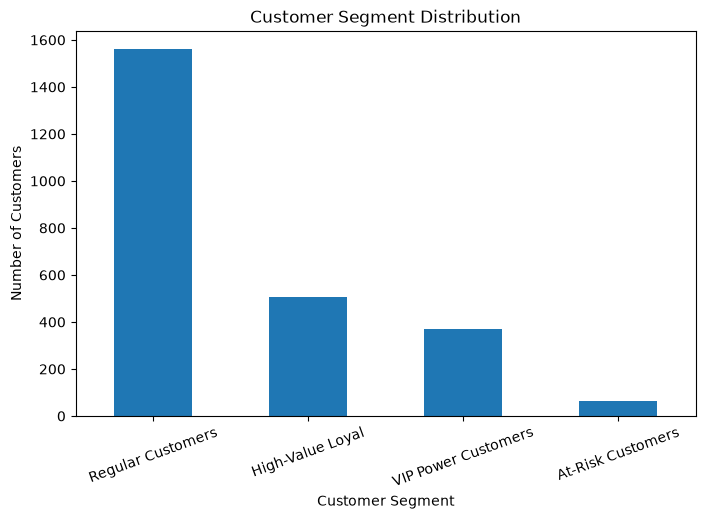

In [23]:
plt.figure(figsize=(8,5))

customer["segment_name"].value_counts().plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

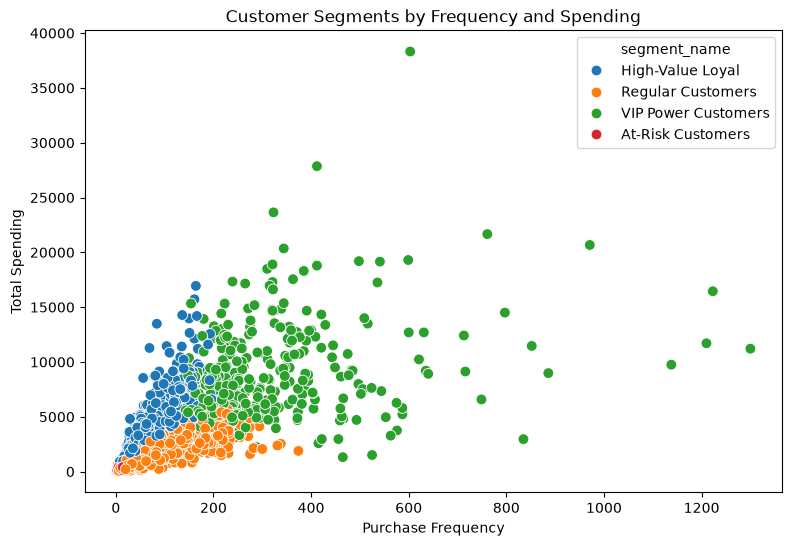

In [24]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=customer,
    x="frequency",
    y="monetary",
    hue="segment_name",
    s=60
)

plt.title("Customer Segments by Frequency and Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")

plt.show()


In [25]:
print([c for c in customer.columns if "campaign" in c.lower() or "respond" in c.lower()])

['campaigns_received', 'campaign_types', 'campaign_rate', 'coupon_per_campaign']


In [26]:
customer["responded_to_campaign"] = 0

customer.loc[
    customer["coupon_redemptions"] > 0,
    "responded_to_campaign"
] = 1

In [27]:
customer["responded_to_campaign"].value_counts()

responded_to_campaign
0    2066
1     434
Name: count, dtype: int64

In [28]:
response_by_segment = customer.groupby("segment_name")["responded_to_campaign"].mean() * 100
response_by_segment

segment_name
At-Risk Customers       0.000000
High-Value Loyal       28.796844
Regular Customers       6.858974
VIP Power Customers    49.051491
Name: responded_to_campaign, dtype: float64

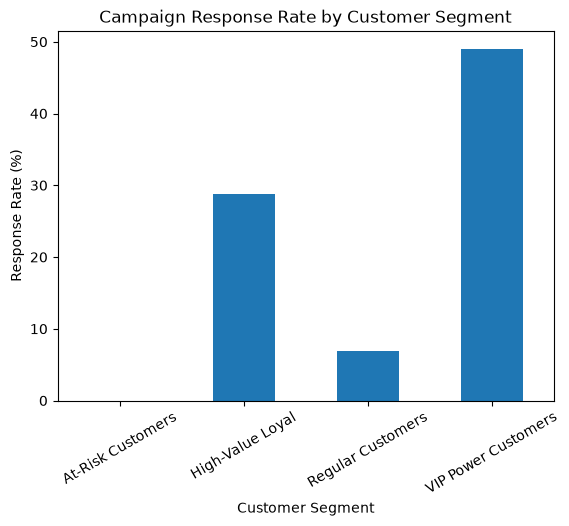

In [29]:
response_by_segment.plot(kind="bar")

plt.title("Campaign Response Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [30]:
segment_spending = customer.groupby("segment_name")["monetary"].mean()
segment_spending.sort_values(ascending=False)

segment_name
VIP Power Customers    8591.961843
High-Value Loyal       4452.674418
Regular Customers      1674.703615
At-Risk Customers       265.399844
Name: monetary, dtype: float64

In [31]:
segment_summary = customer.groupby("segment_name").agg(
    customers=("household_key", "count"),
    avg_spending=("monetary", "mean")
)

segment_summary.sort_values("avg_spending", ascending=False)

,customers,avg_spending
segment_name,,
VIP Power Customers,369,8591.961843
High-Value Loyal,507,4452.674418
Regular Customers,1560,1674.703615
At-Risk Customers,64,265.399844


In [32]:
customer.to_csv(
    "../data/processed/customer_final.csv",
    index=False
)

print("Final dataset saved!")
print(customer.shape)

Final dataset saved!
(2500, 33)


In [33]:
print(customer.columns.tolist())

['household_key', 'recency', 'frequency', 'monetary', 'avg_basket_value', 'total_quantity', 'avg_quantity', 'total_discount', 'discount_rate', 'unique_products', 'shopping_days', 'spend_per_day', 'coupon_redemptions', 'coupon_rate', 'classification_1', 'classification_2', 'classification_3', 'HOMEOWNER_DESC', 'classification_5', 'classification_4', 'KID_CATEGORY_DESC', 'campaigns_received', 'campaign_types', 'coupon_redeemer', 'campaign_rate', 'coupon_per_campaign', 'unique_departments', 'unique_categories', 'unique_brands', 'category_diversity', 'segment', 'segment_name', 'responded_to_campaign']


## Business Recommendations

### 1. Prioritize VIP Power Customers
VIP Power Customers show the highest campaign response rate (49.05%), highest average spending, and highest purchase frequency. Marketing campaigns should prioritize this segment with personalized offers, loyalty rewards, and premium promotions.

### 2. Retain High-Value Loyal Customers
High-Value Loyal customers demonstrate strong spending and a 28.80% campaign response rate. Targeted promotions and loyalty incentives can help maintain engagement and increase customer lifetime value.

### 3. Optimize Campaign Spend for Regular Customers
Regular Customers represent the largest customer segment but have a relatively low campaign response rate of 6.86%. Broad campaigns may be inefficient for this group; targeted offers based on purchase behavior can improve campaign effectiveness.

### 4. Re-engage At-Risk Customers Selectively
At-Risk Customers show very low purchasing activity, high recency, and a 0% observed campaign response rate. Instead of repeated standard campaigns, specialized win-back strategies should be tested selectively.

### 5. Use Predictive Targeting
The campaign-response model can be used to identify customers with a higher probability of responding. Combining predictive scores with customer segments can help prioritize marketing resources toward customers with greater expected campaign value.

# Conclusion

ConsumerIQ combines customer-level behavioral feature engineering, RFM-based segmentation, exploratory analysis, and predictive campaign-response modeling to support data-driven marketing decisions.

The segmentation identified four distinct customer groups: VIP Power Customers, High-Value Loyal, Regular Customers, and At-Risk Customers. VIP Power Customers demonstrated the highest spending, purchase frequency, and campaign response rate.

The balanced Random Forest model achieved a ROC-AUC of approximately 0.862 and improved recall for campaign responders, making it more suitable for identifying potential campaign responders in an imbalanced setting.

Overall, ConsumerIQ enables businesses to prioritize valuable customer segments, identify likely campaign responders, and allocate marketing resources more effectively.